### Analisis de procesamiento de señales - UNSAM <img src=./logo_UNSAM.jpg align=right width=150>
## TS4: Análisis de Fourier: Primeras nociones de estimación espectral
### Lanzavechia, Jerónimo

Aclaración: El formateo de los gráficos y las porciones del documento en Latex se hicieron con asistencia de Chat-GPT

## Introducción

En la teoría, las señales pueden representarse como funciones continuas e infinitamente densas, con un dominio continuo desde el $-\infty$ al $+\infty$. Analizar señales en la realidad implica que dichos fundamentos matemáticos no se cumplan, creando la necesidad de crear herramientas para estimar, por ejemplo, el valor de dicha señal a lo largo del tiempo, o para el caso de este trabajo semanal, su espectro.

La estimación espectral nace de que una señal no se puede analizar a infinito tiempo, y que las frecuencias no pueden analizarse de forma continua. El ventaneo y el muestreo de frecuencia darán lugar a cierta incertidumbre en el analisis de una señal en su dominio frecuencial.
Durante el proceso de estimación, podria ser de interés estimar con cierta selectividad el espectro, por ejemplo, tratando de aislar la señal de interés de cierto ruido, o querer poder distinguir de mejor forma las componentes del espectro. Para esto, se podría elegir alguna ventana particular. Esta selección en la ventana trae consigo dos cuestiones a considerar. Si la estimación esta muy alejada del "valor deseado" (aquel que se espera o se intuye/sabe que tiene el elemento a medir), se dice que hay cierto sesgo en la estimación. Si los valores de la medición varían mucho o poco de nuestro "valor deseado", se dice que hay mucha varianza en la estimación.

Para este trabajo semanal, se implementarán distintas ventanas con el objetivo de ver y comparar el sesgo y la varianza que presentan en la estimación espectral de señales de distintos SNR.

## Desarrollo
Se realizarán 200 realizaciones de señales de SNR = 3dB y SNR = 10dB a las cuales se les aplicará una ventana particular. Dicho ventaneo, y el número de realizaciones permitiran estimar el espectro de la señal, junto con un sesgo y una varianza correspondientes. Se buscará estimar la amplitud y la frecuencia de las señales. 

Las señales se presentan con la siguiente formula:

\begin{align}
    x(n)=a_0⋅sen(Ω_1⋅n)+n_a(n)
\end{align}

donde $Ω_1$ esta compuesto por:

\begin{align}
    Ω_1=Ω_0+f_r⋅2π/N
\end{align}

con $Ω_0 = π/2$ y con f_r dado por la siguiente distribución:

\begin{align}
    f_r∼\mathcal{U}(−2,2)
\end{align}

Será la variación de frecuencia.

Como la potencia será unitaria, $a_0=√2$

$n_a(n)$ estará dado por:
\begin{align}
    n_a(n)∼\mathcal{N}(0,\sigma²)
\end{align}

Será el ruido de la señal, $\sigma²$ es la varianza del mismo.

Tanto la variación de la frecuencia como el ruido serán generados con la función "mi_ruido" en mi_libreria.py.

In [ ]:
#hecha para TS1
def mi_ruido(P,dist,dc,n,fs):
    """
    P = Potencia de la señal
    dc = componente de continua
    dist = distribucion (normal, uniform)
    n = numero de muestras
    """
    noise = []
    if dist == "normal":    
        for i in range(n):
            noise.append(np.random.normal(0,np.sqrt(P)) + dc)
    elif dist == "uniform":
        for i in range(n):
            A = np.sqrt(P*3)
            noise.append(np.random.uniform(-A,A) + dc)
            #La potencia media de una distribucion uniforme es (vmax - vmin)²/12
            #despejando, siendo que vmax = -vmin, queda que P = 4vmax²/12
            #simplificando, P = vmax²/3
            #la vmax me da una amplitud, siendo que la distribucion la centro en dc,
            #entonces vmax = A = sqrt(P*3)
    else:
        print("Distribucion no disponible")
        return noise
    
    tt =  np.arange(start = 0, stop = n/fs, step = 1/fs)
    return tt, noise

Para realizar las estimaciones de amplitud y frecuencia, se piden implementar los siguientes estimadores:

El de amplitud buscará en las 200 realizaciones los valores en $f = 250Hz$, por lo tanto, puede interpretarse como:
\begin{align}
   {\hat a}_0 =|X^i_w(Ω_0)|
\end{align}
A partir del cual se obtiene el sesgo de la siguiente forma, calculando su valor esperado(el promedio entre las amplitudes en $250Hz$):

\begin{align}
E\{ \hat{a_0}\} = \hat{\mu_a} = \frac{1}{R} \sum^{R-1}_{j=0} \hat{a_{j}}
\end{align}

\begin{align}
S_a = \mathop{E}\{ {\hat a}_0 \}  − a_0
\end{align}

Con varianza calculada desde np.var() usando esos valores, disponible en numpy

Y el de frecuencia buscará el argumento con mayor amplitud para las 200 realizaciones:

\begin{align}
\hat{Ω}^i_1 = \mathop{arg\ max}_f \{ \lvert X^i_w(Ω) \rvert \}
\end{align}

El sesgo y la varianza se calculan de la misma forma que para la amplitud.
Los valores medidos por el estimador de frecuencias se usarán para un histograma, y todos los sesgos y varianzas estarán en un tablas correspondientes a cada SNR.


Se utilizarán las siguientes librerías y constantes:

In [4]:
import numpy as np #importa numpy
import matplotlib.pyplot as plt #importa plot
import mi_libreria as lib #importa mi_libreria
import scipy.fft as scfft #mporta scipy para la fft
import scipy.signal.windows as window #importa scipy para ventanas

N = 1000 #número de muestras por realización
R = 200 #realizaciones
fs = 1000 #f de muestreo
A = np.sqrt(2) #amplitud del seno para 1W

### Señal con SNR = 3DB

Para generar las 200 realizaciones a 1000 muestras cada una, se creó una matriz R x N producto de las realizaciones (cada una con una $f_r$ distinta) y la cantidad de muestras. Esta matriz luego se usó para la implementación de los 200 senos, a los cuales se les adicionó la matriz de R x N muestras de ruido ruidos, uno para cada realización. Se calculó la potencia requerida para el ruido a partir del SNR deseado, y se pasó a la función mi_ruido como parámetro.


In [6]:
#En la implementacion agregue para generar una uniforme, asi que la uso para eso

SNR = 3 #el seno tiene potencia 1W
P_ruido = 1 * 10**(-SNR/10)

tt,na_3dB = lib.mi_ruido(P_ruido, "normal", 0, N, fs)

####################para la frecuencia################
P = 2 #lo imagino como si tuviera una potencia de 2

tt,u = lib.mi_ruido(P, "uniform" , 0, R, fs) ##frecuencia

fr = np.pi/2 + np.array(u)*2*np.pi/N

nn = np.arange(start = 0, stop = N, step = 1)

fr_x_n = nn.reshape(1,N) * fr.reshape(R,1) #NxR
###################para la frecuencia#################

#los 200 ruidos
na_3dB_m = np.random.normal(0,np.sqrt(P_ruido),size=(R,N))

##los 200 senos
senos = A * np.sin(fr_x_n) + na_3dB_m

### analisis

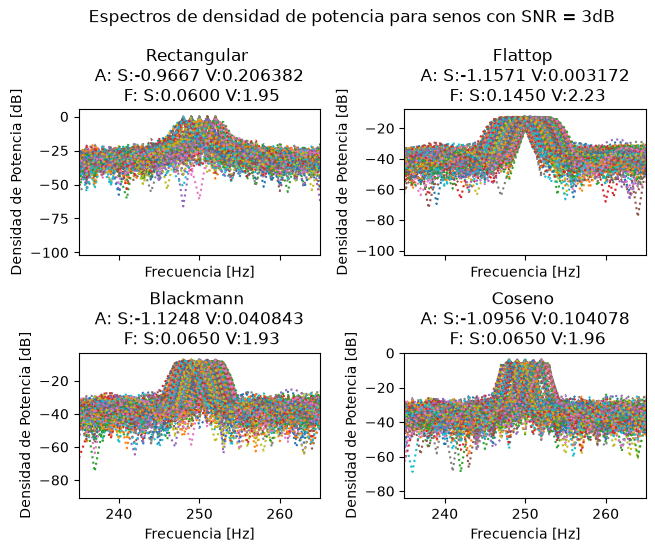

In [31]:
fig_3SNR, ((rectangular_3, flattop_3),( blackmann_3, coseno_3)) = plt.subplots(2,2, sharex=True)
fig_3SNR.suptitle("Espectros de densidad de potencia para senos con SNR = 3dB", y = 1.1)
fig_3SNR.tight_layout(h_pad = 6, w_pad = 3)

#ventana rectangular
#al ventanear por una rectangular de N, es lo mismo que ver la funcion por la 
#ventana

seno_x_rectangular =  senos

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_rectangular,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)


##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_rec = a - A

##varianza
V_a_rec = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_rec = []
for i in range(200):
    f_max_rec.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_rec = np.array(f_max_rec)

#sesgo

E_a = (1 / R) *np.sum(f_max_rec)
S_f_rec = E_a - N/4

#varianza

V_f_rec = np.var(f_max_rec)

########plot#############

rectangular_3.set_title(f"Rectangular \n A: S:{S_a_rec:.4f} V:{V_a_rec:.6f} \n F: S:{S_f_rec:.4f} V:{V_f_rec:.2f}")
rectangular_3.set_xlabel("Frecuencia [Hz]")
rectangular_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    rectangular_3.plot(ww,modulo_db[i],':')
rectangular_3.set_xlim(235*fs/N,265*fs/N) #comparten los ejes, los acerco en ese rango de x para ver la forma del espectro#
##############################################################################

#ventana flattop
flattop = window.flattop(N)

seno_x_flattop =  senos * flattop 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_flattop ,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_flat = a - A

##varianza
V_a_flat = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_flat = []
for i in range(200):
    f_max_flat.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_flat = np.array(f_max_flat)

#sesgo

E_a = (1 / R) *np.sum(f_max_flat)
S_f_flat = E_a - N/4

#varianza

V_f_flat = np.var(f_max_flat)

########plot#############

flattop_3.set_title(f"Flattop \n A: S:{S_a_flat:.4f} V:{V_a_flat:.6f} \n F: S:{S_f_flat:.4f} V:{V_f_flat:.2f}")
flattop_3.set_xlabel("Frecuencia [Hz]")
flattop_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    flattop_3.plot(ww,modulo_db[i],':')

##############################################################################


#ventana blackmanharris

blackmanharris = window.blackman(N)

seno_x_blackmanharris =  senos * blackmanharris 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_blackmanharris,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_black = a - A

##varianza
V_a_black = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_black = []
for i in range(200):
    f_max_black.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_black = np.array(f_max_black)

#sesgo

E_a = (1 / R) *np.sum(f_max_black)
S_f_black = E_a - N/4

#varianza

V_f_black = np.var(f_max_black)

########plot#############

blackmann_3.set_title(f"Blackmann \n A: S:{S_a_black:.4f} V:{V_a_black:.6f} \n F: S:{S_f_black:.4f} V:{V_f_black:.2f}")
blackmann_3.set_xlabel("Frecuencia [Hz]")
blackmann_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    blackmann_3.plot(ww,modulo_db[i],':')

#############################################################################

#Ventana a eleccion: 

cosine = window.cosine(N)

seno_x_cosine = senos * cosine

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_cosine,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_cos = a - A

##varianza
V_a_cos = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_cos = []
for i in range(200):
    f_max_cos.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_cos = np.array(f_max_cos)

#sesgo

E_a = (1 / R) *np.sum(f_max_cos)
S_f_cos = E_a - N/4

#varianza

V_f_cos = np.var(f_max_cos)

########plot#############

coseno_3.set_title(f"Coseno \n A: S:{S_a_cos:.4f} V:{V_a_cos:.6f} \n F: S:{S_f_cos:.4f} V:{V_f_cos:.2f}")
coseno_3.set_xlabel("Frecuencia [Hz]")
coseno_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    coseno_3.plot(ww,modulo_db[i],':')
#############################################################################

### Histograma

(array([33.,  0., 42.,  0.,  0., 46.,  0., 38.,  0., 41.]),
 array([248. , 248.4, 248.8, 249.2, 249.6, 250. , 250.4, 250.8, 251.2,
        251.6, 252. ]),
 [<matplotlib.patches.Polygon at 0x721985717b90>])

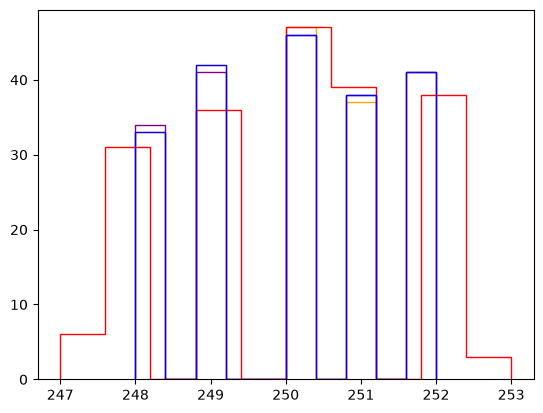

In [4]:
plt.figure(10)
plt.hist(f_max_rec, color = 'orange', histtype='step')
plt.hist(f_max_flat, color = 'red', histtype='step')
plt.hist(f_max_black, color = 'purple', histtype='step')
plt.hist(f_max_cos, color = 'blue', histtype='step')

### Señal con SNR = 10dB

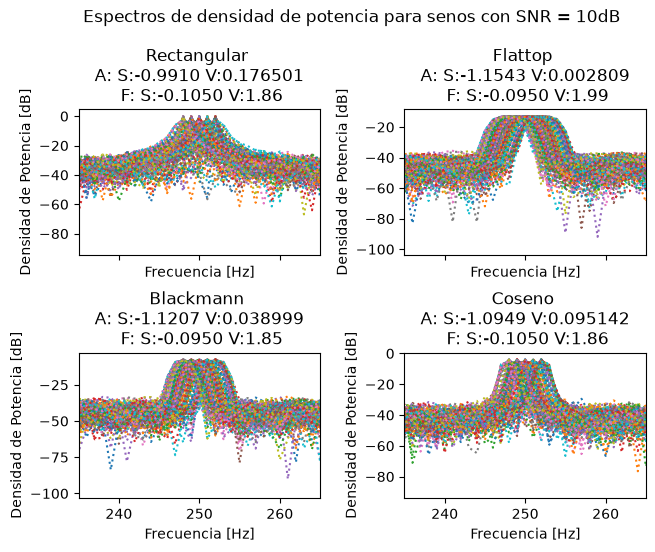

In [33]:
N = 1000
fs = 1000
A = np.sqrt(2)

#En la implementacion agregue para generar una uniforme, asi que la uso para eso
P = 2

SNR = 10 #el seno tiene potencia 1W
P_ruido = 1 * 10**(-SNR/10)

tt,na_3dB = lib.mi_ruido(P_ruido, "normal", 0, N, fs)

#En la implementacion agregue para generar una uniforme, asi que la uso para eso
R = 200

####################para la frecuencia################
tt,u = lib.mi_ruido(P, "uniform" , 0, R, fs) ##frecuencia

fr = np.pi/2 + np.array(u)*2*np.pi/N

nn = np.arange(start = 0, stop = N, step = 1)

fr_x_n = nn.reshape(1,N) * fr.reshape(R,1) #NxR
###################para la frecuencia#################

#los 200 ruidos
na_10dB_m = np.random.normal(0,np.sqrt(P_ruido),size=(R,N))

##los 200 senos
senos = A * np.sin(fr_x_n) + na_10dB_m

#Ventanas SNR = 10dB

fig_10SNR, ((rectangular_10, flattop_10),( blackmann_10, coseno_10)) = plt.subplots(2,2, sharex=True)
fig_10SNR.suptitle("Espectros de densidad de potencia para senos con SNR = 10dB", y = 1.1)
fig_10SNR.tight_layout(h_pad = 6, w_pad = 3)

#ventana rectangular
#al ventanear por una rectangular de N, es lo mismo que ver la funcion por la 
#ventana

seno_x_rectangular =  senos

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_rectangular,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)


##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_rec = a - A

##varianza
V_a_rec = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_rec = []
for i in range(200):
    f_max_rec.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_rec = np.array(f_max_rec)

#sesgo

E_a = (1 / R) *np.sum(f_max_rec)
S_f_rec = E_a - N/4

#varianza

V_f_rec = np.var(f_max_rec)

########plot#############

rectangular_10.set_title(f"Rectangular \n A: S:{S_a_rec:.4f} V:{V_a_rec:.6f} \n F: S:{S_f_rec:.4f} V:{V_f_rec:.2f}")
rectangular_10.set_xlabel("Frecuencia [Hz]")
rectangular_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    rectangular_10.plot(ww,modulo_db[i],':')
rectangular_10.set_xlim(235*fs/N,265*fs/N) #comparten los ejes, los acerco en ese rango de x para ver la forma del espectro#
##############################################################################

#ventana flattop
flattop = window.flattop(N)

seno_x_flattop =  senos * flattop 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_flattop ,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_flat = a - A

##varianza
V_a_flat = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_flat = []
for i in range(200):
    f_max_flat.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_flat = np.array(f_max_flat)

#sesgo

E_a = (1 / R) *np.sum(f_max_flat)
S_f_flat = E_a - N/4

#varianza

V_f_flat = np.var(f_max_flat)

########plot#############

flattop_10.set_title(f"Flattop \n A: S:{S_a_flat:.4f} V:{V_a_flat:.6f} \n F: S:{S_f_flat:.4f} V:{V_f_flat:.2f}")
flattop_10.set_xlabel("Frecuencia [Hz]")
flattop_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    flattop_10.plot(ww,modulo_db[i],':')

##############################################################################

#ventana blackmanharris

blackmanharris = window.blackman(N)

seno_x_blackmanharris =  senos * blackmanharris 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_blackmanharris,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_black = a - A

##varianza
V_a_black = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_black = []
for i in range(200):
    f_max_black.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_black = np.array(f_max_black)

#sesgo

E_a = (1 / R) *np.sum(f_max_black)
S_f_black = E_a - N/4

#varianza

V_f_black = np.var(f_max_black)

########plot#############

blackmann_10.set_title(f"Blackmann \n A: S:{S_a_black:.4f} V:{V_a_black:.6f} \n F: S:{S_f_black:.4f} V:{V_f_black:.2f}")
blackmann_10.set_xlabel("Frecuencia [Hz]")
blackmann_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    blackmann_10.plot(ww,modulo_db[i],':')

#############################################################################

#Ventana a eleccion: 

cosine = window.cosine(N)

seno_x_cosine = senos * cosine

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_cosine,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_cos = a - A

##varianza
V_a_cos = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_cos = []
for i in range(200):
    f_max_cos.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_cos = np.array(f_max_cos)

#sesgo

E_a = (1 / R) *np.sum(f_max_cos)
S_f_cos = E_a - N/4

#varianza

V_f_cos = np.var(f_max_cos)

########plot#############

coseno_10.set_title(f"Coseno \n A: S:{S_a_cos:.4f} V:{V_a_cos:.6f} \n F: S:{S_f_cos:.4f} V:{V_f_cos:.2f}")
coseno_10.set_xlabel("Frecuencia [Hz]")
coseno_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    coseno_10.plot(ww,modulo_db[i],':')
#############################################################################

### Histograma

(array([47.,  0., 36.,  0.,  0., 38.,  0., 45.,  0., 34.]),
 array([248. , 248.4, 248.8, 249.2, 249.6, 250. , 250.4, 250.8, 251.2,
        251.6, 252. ]),
 [<matplotlib.patches.Polygon at 0x7219851b4bc0>])

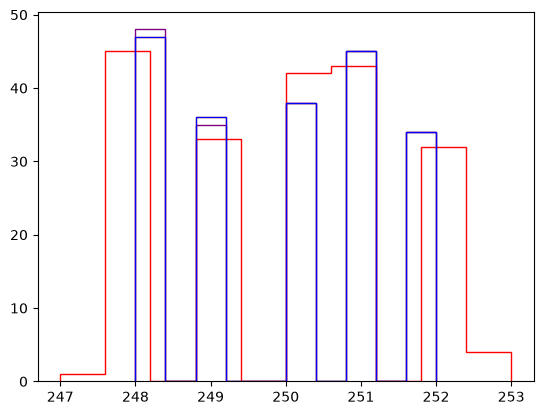

In [6]:
plt.figure(40)
plt.hist(f_max_rec, color = 'orange', histtype='step')
plt.hist(f_max_flat, color = 'red', histtype='step')
plt.hist(f_max_black, color = 'purple', histtype='step')
plt.hist(f_max_cos, color = 'blue', histtype='step')

## Estimaciones

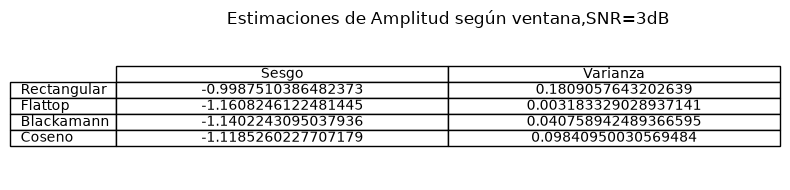

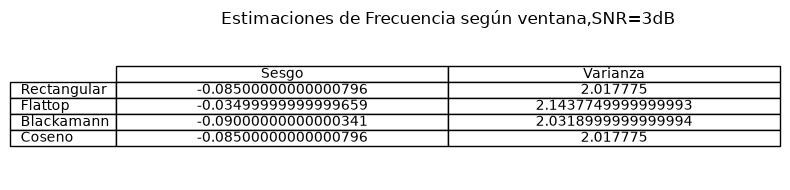

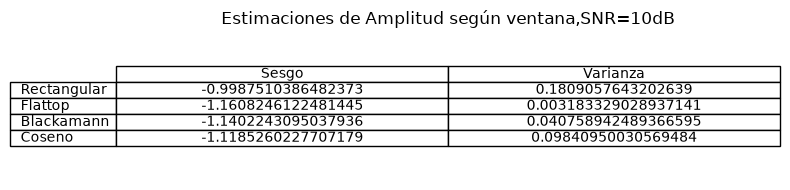

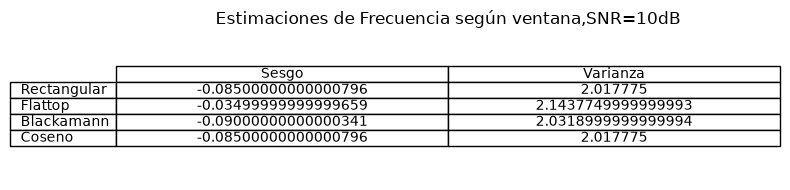

In [7]:
#Tablas de comparacion de amplitud/frecuencia y varianza

##arreglos de datos para tablas
datos_a = [(S_a_rec,V_a_rec),(S_a_flat, V_a_flat),(S_a_black,V_a_black),(S_a_cos,V_a_cos)]

datos_f = [(S_f_rec,V_f_rec),(S_f_flat, V_f_flat),(S_f_black,V_f_black),(S_f_cos,V_f_cos)]

##tabla estimacion amplitud
plt.figure(20,figsize=(8,2))
plt.title("Estimaciones de Amplitud según ventana,SNR=3dB")
tabla_a_3dB = plt.table(
    cellText=(datos_a),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )
plt.axis('off')
plt.tight_layout()
plt.show()

##tabla estimacion frecuencia
plt.figure(30,figsize=(8,2))
plt.title("Estimaciones de Frecuencia según ventana,SNR=3dB")
tabla_a_3dB = plt.table(
    cellText=(datos_f),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )

plt.axis('off')
plt.tight_layout()
plt.show()




##arreglos de datos para tablas

datos_a = [(S_a_rec,V_a_rec),(S_a_flat, V_a_flat),(S_a_black,V_a_black),(S_a_cos,V_a_cos)]

datos_f = [(S_f_rec,V_f_rec),(S_f_flat, V_f_flat),(S_f_black,V_f_black),(S_f_cos,V_f_cos)]

##tabla estimacion amplitud
plt.figure(50,figsize=(8,2))
plt.title("Estimaciones de Amplitud según ventana,SNR=10dB")
tabla_a_10dB = plt.table(
    cellText=(datos_a),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )
plt.axis('off')
plt.tight_layout()
plt.show()

##tabla estimacion frecuencia
plt.figure(60,figsize=(8,2))
plt.title("Estimaciones de Frecuencia según ventana,SNR=10dB")
tabla_f_10dB = plt.table(
    cellText=(datos_f),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )

plt.axis('off')
plt.tight_layout()
plt.show()

## Conclusiones

## Referencias
* Holton, Thomas (2021). Digital Signal Processing - Principles and Applications. Cambridge University Press